In [327]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.decomposition import PCA, IncrementalPCA

import sys
sys.path.append(r"D:\master-AI\online PCA")
from online_psp.online_psp.fast_similarity_matching import FSM

import torch
from tools.oja_pca import OjaPCA

import online_svd_buffer as op
import group_svd as group_op

np.set_printoptions(suppress=True, precision=4, linewidth=200)

In [328]:
# DATA_DIR = "datasets/arxiv_embeddings"
# DATA_DIR = "datasets/cifar10"
# DATA_DIR = "datasets/isolet"
# DATA_DIR = "datasets/yearprediction"
# DATA_DIR = "datasets/gas_sensor"
# DATA_DIR = "datasets/har"
# DATA_DIR = "datasets/fashion_mnist" 
# DATA_DIR = "datasets/news20" 
DATA_DIR = "datasets/synthetic"
FILE_PATTERN = "X_{:04d}.npy"
HOLDOUT_FILE = 0
NUM_FILES = len(os.listdir(DATA_DIR))

P = 15

# old pairwise OnlinePCA iterations per streaming batch
G = 500

# new group/block iterations per streaming batch
# One group update is heavier than one pairwise update.
# A reasonable first comparison is G // P.
GROUP_G = max(1, G // P)

# streaming batch sizes
ONLINE_BATCH = 3000
GROUP_BATCH  = 3000
IPCA_BATCH   = 3000
OJA_BATCH    = 3000

# monitor set
MONITOR_ROWS = 2000
EVAL_EVERY = 1

print("Pairwise G:", G)
print("Group G:", GROUP_G)

Pairwise G: 500
Group G: 33


In [35]:
def iter_chunks(include_holdout=False):
    for i in range(NUM_FILES):
        if not include_holdout and i == HOLDOUT_FILE:
            continue
        path = os.path.join(DATA_DIR, FILE_PATTERN.format(i))
        yield np.load(path)  # shape: (N, d)


first_train = np.load(os.path.join(DATA_DIR, FILE_PATTERN.format(0)))
N0, d = first_train.shape
TOTAL_SAMPLES = (NUM_FILES - 1) * N0

holdout = np.load(os.path.join(DATA_DIR, FILE_PATTERN.format(HOLDOUT_FILE)))
monitor = holdout[:MONITOR_ROWS].T.astype(np.float32, copy=False)  # shape: (d, m)

print("Train chunk shape:", first_train.shape)
print("Holdout chunk shape:", holdout.shape)
print("d =", d)
print("Monitor shape:", monitor.shape)
print("Training samples:", TOTAL_SAMPLES)

Train chunk shape: (2000, 128)
Holdout chunk shape: (2000, 128)
d = 128
Monitor shape: (128, 2000)
Training samples: 12000


In [36]:
def evr_from_recon(X_true, X_recon):
    err = np.linalg.norm(X_true - X_recon, "fro") ** 2
    tot = np.linalg.norm(X_true, "fro") ** 2
    return 1.0 - err / tot


def evr_from_U(X_mon, U, p):
    """
    X_mon: (d, m)
    U:     (d, d) or (d, p)
    """
    U_p = U[:, :p]
    Z = U_p.T @ X_mon
    X_rec = U_p @ Z
    return evr_from_recon(X_mon, X_rec)

In [37]:
def load_all_as_X_float32():
    blocks = []
    for chunk in tqdm(iter_chunks(), total=NUM_FILES - 1, desc="Loading chunks"):
        blocks.append(chunk.astype(np.float32, copy=False).T)  # (d, N)
    return np.hstack(blocks)  # (d, totalN)


X = load_all_as_X_float32()
print("X:", X.shape, X.dtype)

Loading chunks: 100%|██████████| 6/6 [00:00<00:00, 101.29it/s]

X: (128, 11910) float32


In [38]:
def fit_safe(x, p, n_iter, u, scores, row_topk_vals, row_topk_idx, TEMP_COL):
    """
    Safe wrapper around your existing pairwise/top-k method.

    It preserves your current heuristic, but guards against invalid jq.
    """
    d_local = x.shape[0]
    n_active = x.shape[1]

    op.compute_and_assign_topk_cf(p, x, scores, row_topk_vals, row_topk_idx)

    for _ in range(n_iter):
        iq, jq = op.get_max_topk(row_topk_vals, row_topk_idx)

        if iq == -1 or jq == -1:
            break

        guard = 0
        while jq >= n_active:
            row_topk_vals[iq, 0] = op.NEG_INF32
            row_topk_idx[iq, 0] = -1

            iq, jq = op.get_max_topk(row_topk_vals, row_topk_idx)

            if iq == -1 or jq == -1:
                return u, x

            guard += 1
            if guard > 10000:
                raise RuntimeError("Too many invalid pivot reselections; check score bookkeeping.")

        if jq >= d_local:
            xji = 0.0
            xjj = 0.0
        else:
            xji = x[jq, iq]
            xjj = x[jq, jq]

        t = np.zeros((2, 2), dtype=np.float64)
        t[0, 0] = x[iq, iq]
        t[0, 1] = x[iq, jq]
        t[1, 0] = xji
        t[1, 1] = xjj

        G_local, _, H_local = np.linalg.svd(t)

        op.mul_update_numba(
            x,
            iq,
            jq,
            H_local,
            G_local,
            u,
            d_local,
            n_active,
            p,
            scores,
            row_topk_vals,
            row_topk_idx,
            TEMP_COL,
        )

    return u, x

In [39]:
print("Warmup...")

tmp = X[:, :5000].astype(np.float64, copy=True)
monitor64 = monitor.astype(np.float64, copy=False)

# Warm up your existing numba pairwise method
op.set_num_threads(op.NUMBA_THREADS)

# IMPORTANT:
# TEMP_ROW must be at least tmp.shape[1]
# TEMP_COL must be at least tmp.shape[0]
op._init_global_buf(tmp.shape[0], tmp.shape[1], np.float64)

scores_tmp = np.empty((5, tmp.shape[1]), dtype=np.float64)
scores_tmp.fill(op.NEG_INF32)

row_topk_vals_tmp = np.empty((5, op.TOP_K_SCORES), dtype=np.float64)
row_topk_vals_tmp.fill(op.NEG_INF32)

row_topk_idx_tmp = np.empty((5, op.TOP_K_SCORES), dtype=np.int64)
row_topk_idx_tmp.fill(-1)

u_tmp = np.identity(tmp.shape[0], dtype=np.float64)

_ = fit_safe(
    tmp,
    p=5,
    n_iter=10,
    u=u_tmp,
    scores=scores_tmp,
    row_topk_vals=row_topk_vals_tmp,
    row_topk_idx=row_topk_idx_tmp,
    TEMP_COL=op.TEMP_COL,
)

# Warm up new group method from imported file
u_tmp2 = np.identity(tmp.shape[0], dtype=np.float64)

_ = group_op.fit_group_full_recompute(
    tmp.copy(),
    p=5,
    n_iter=2,
    u=u_tmp2,
)

print("Warmup done.")

Warmup...
Warmup done.


In [40]:
print("Running OnlinePCA (time + samples tracked)...")

online_tr = []
online_time_axis = []
online_samples = []

t_start = time.perf_counter()

d_local = X.shape[0]
batch_size = max(ONLINE_BATCH, d_local)

op.set_num_threads(op.NUMBA_THREADS)
op._init_global_buf(d_local, batch_size + P, np.float64)

start_index = 0
end_index = min(batch_size, X.shape[1])

x = X[:, start_index:end_index]
x_batch = np.array(x, copy=True).astype(np.float64)
u = np.identity(d_local)

scores = np.empty((P, X.shape[1]), dtype=np.float64)
scores.fill(op.NEG_INF32)

row_topk_vals = np.empty((P, op.TOP_K_SCORES), dtype=np.float64)
row_topk_vals.fill(op.NEG_INF32)

row_topk_idx = np.empty((P, op.TOP_K_SCORES), dtype=np.int64)
row_topk_idx.fill(-1)

samples_seen = 0
total_batches = X.shape[1] // batch_size + (1 if X.shape[1] % batch_size else 0)

for bi in tqdm(range(total_batches), desc="OnlinePCA batches"):
    t0 = time.perf_counter()
    u, x = fit_safe(
        x_batch,
        P,
        G,
        u,
        scores,
        row_topk_vals,
        row_topk_idx,
        op.TEMP_COL,
    )
    t1 = time.perf_counter()

    samples_seen += end_index - start_index

    online_time_axis.append(t1 - t_start)
    online_samples.append(samples_seen)

    # EVR not timed
    online_tr.append(evr_from_U(monitor.astype(np.float64), u, P))

    if end_index == X.shape[1]:
        break

    start_index += batch_size
    end_index = min(end_index + batch_size, X.shape[1])

    x_batch = np.hstack((
        x[:, :P],
        u.T @ X[:, start_index:end_index]
    )).astype(np.float64)

online_time_axis = np.array(online_time_axis)
online_samples = np.array(online_samples)
online_tr = np.array(online_tr)

print("OnlinePCA done.")

Running OnlinePCA (time + samples tracked)...


OnlinePCA batches:  75%|███████▌  | 3/4 [00:00<00:00,  4.40it/s]

OnlinePCA done.


In [41]:
# %%
print("Running GroupOnlineSVD full-recompute method...")

group_tr = []
group_time_axis = []
group_samples = []

fit_time_accum = 0.0

d_local = X.shape[0]
batch_size = max(GROUP_BATCH, d_local)

start_index = 0
end_index = min(batch_size, X.shape[1])

x = X[:, start_index:end_index]
x_batch = np.array(x, copy=True).astype(np.float64, copy=False)
u_group = np.identity(d_local, dtype=np.float64)

samples_seen = 0

total_batches = X.shape[1] // batch_size + (1 if X.shape[1] % batch_size else 0)

for bi in tqdm(range(total_batches), desc="GroupOnlineSVD batches"):
    t0 = time.perf_counter()
    u_group, x = group_op.fit_group_full_recompute(
        x_batch,
        p=P,
        n_iter=GROUP_G,
        u=u_group,
    )
    t1 = time.perf_counter()

    fit_time_accum += t1 - t0
    samples_seen += end_index - start_index

    group_time_axis.append(fit_time_accum)
    group_samples.append(samples_seen)

    # EVR not timed
    group_tr.append(evr_from_U(monitor64, u_group, P))

    if end_index == X.shape[1]:
        break

    start_index += batch_size
    end_index = min(end_index + batch_size, X.shape[1])

    x_batch = np.hstack((
        x[:, :P],
        u_group.T @ X[:, start_index:end_index]
    )).astype(np.float64, copy=False)

group_time_axis = np.array(group_time_axis)
group_samples = np.array(group_samples)
group_tr = np.array(group_tr)

print("GroupOnlineSVD done.")
print("Final EVR:", group_tr[-1])
print("Fit time:", group_time_axis[-1])

Running GroupOnlineSVD full-recompute method...


GroupOnlineSVD batches:  75%|███████▌  | 3/4 [00:00<00:00, 22.52it/s]

GroupOnlineSVD done.
Final EVR: 0.9999893860790845
Fit time: 0.10067690000869334


In [42]:
# %%
print("Running IncrementalPCA...")

ipca = IncrementalPCA(n_components=P, batch_size=IPCA_BATCH)

ipca_tr = []
ipca_time_axis = []
ipca_samples = []

fit_time_accum = 0.0
samples_seen = 0

for chunk in tqdm(iter_chunks(), total=NUM_FILES - 1, desc="IPCA chunks"):
    chunk = chunk.astype(np.float32, copy=False)
    N = chunk.shape[0]

    for start in range(0, N, IPCA_BATCH):
        batch = chunk[start:start + IPCA_BATCH]

        t0 = time.perf_counter()
        ipca.partial_fit(batch)
        t1 = time.perf_counter()

        fit_time_accum += t1 - t0
        samples_seen += batch.shape[0]

        ipca_time_axis.append(fit_time_accum)
        ipca_samples.append(samples_seen)

        # EVR not timed
        Z = ipca.transform(monitor.T)
        mon_rec = ipca.inverse_transform(Z).T
        ipca_tr.append(evr_from_recon(monitor, mon_rec))

ipca_time_axis = np.array(ipca_time_axis)
ipca_samples = np.array(ipca_samples)
ipca_tr = np.array(ipca_tr)

print("IncrementalPCA done.")
print("Final EVR:", ipca_tr[-1])
print("Fit time:", ipca_time_axis[-1])

Running IncrementalPCA...


IPCA chunks: 100%|██████████| 6/6 [00:00<00:00, 19.58it/s]

IncrementalPCA done.
Final EVR: 0.9999897854868012
Fit time: 0.27834959991741925


In [43]:
# %%
print("Running OjaPCA...")

oja = OjaPCA(n_features=d, n_components=P, eta=0.005)
X_mon_t = torch.tensor(monitor.T, dtype=torch.float32)

oja_tr = []
oja_time_axis = []
oja_samples = []

fit_time_accum = 0.0
samples_seen = 0

for chunk in tqdm(iter_chunks(), total=NUM_FILES - 1, desc="Oja chunks"):
    chunk = chunk.astype(np.float32, copy=False)
    N = chunk.shape[0]

    for start in range(0, N, OJA_BATCH):
        batch_np = chunk[start:start + OJA_BATCH]
        batch_t = torch.tensor(batch_np, dtype=torch.float32)

        t0 = time.perf_counter()
        if hasattr(oja, "forward"):
            oja(batch_t)
        else:
            oja.partial_fit(batch_t)
        t1 = time.perf_counter()

        fit_time_accum += t1 - t0
        samples_seen += batch_np.shape[0]

        oja_time_axis.append(fit_time_accum)
        oja_samples.append(samples_seen)

        # EVR not timed
        with torch.no_grad():
            Z = oja.transform(X_mon_t)
            X_rec = oja.inverse_transform(Z)

        oja_tr.append(evr_from_recon(monitor, np.asarray(X_rec).T))

oja_time_axis = np.array(oja_time_axis)
oja_samples = np.array(oja_samples)
oja_tr = np.array(oja_tr)

print("OjaPCA done.")
print("Final EVR:", oja_tr[-1])
print("Fit time:", oja_time_axis[-1])

Running OjaPCA...


Oja chunks: 100%|██████████| 6/6 [00:00<00:00, 428.60it/s]

OjaPCA done.
Final EVR: 0.99999404
Fit time: 0.004946099827066064


In [44]:
print("Running FSM...")

fsm = FSM(P, d)

fsm_tr = []
fsm_time_axis = []
fsm_samples = []

fit_time_accum = 0.0
samples_seen = 0

for chunk in tqdm(iter_chunks(), total=NUM_FILES - 1, desc="FSM chunks"):
    chunk = chunk.astype(np.float64, copy=False)

    for start in range(0, chunk.shape[0], OJA_BATCH):
        batch = chunk[start:start + OJA_BATCH]

        t0 = time.perf_counter()
        for x_i in batch:
            fsm.fit_next(x_i)
        t1 = time.perf_counter()

        fit_time_accum += t1 - t0
        samples_seen += batch.shape[0]

        fsm_time_axis.append(fit_time_accum)
        fsm_samples.append(samples_seen)

        # EVR not timed
        U_fsm = np.asarray(fsm.get_components())

        if U_fsm.shape == (P, d):
            U_fsm = U_fsm.T
        elif U_fsm.shape != (d, P):
            raise ValueError(f"Unexpected FSM component shape: {U_fsm.shape}")

        fsm_tr.append(evr_from_U(monitor64, U_fsm, P))

fsm_time_axis = np.array(fsm_time_axis)
fsm_samples = np.array(fsm_samples)
fsm_tr = np.array(fsm_tr)

print("FSM done.")
print("Final EVR:", fsm_tr[-1])
print("Fit time:", fsm_time_axis[-1])

Running FSM...


FSM chunks: 100%|██████████| 6/6 [00:00<00:00, 16.06it/s]

FSM done.
Final EVR: 0.9999721840428929
Fit time: 0.22682509990409017


In [45]:
# %%
results = [
    {
        "method": "IncrementalPCA",
        "time": ipca_time_axis[-1],
        "explained_variance": ipca_tr[-1],
    },
    {
        "method": "OjaPCA",
        "time": oja_time_axis[-1],
        "explained_variance": oja_tr[-1],
    },
    {
        "method": "FSM",
        "time": fsm_time_axis[-1],
        "explained_variance": fsm_tr[-1],
    },
    {
        "method": "OnlinePCA pairwise",
        "time": online_time_axis[-1],
        "explained_variance": online_tr[-1],
    },
    {
        "method": "GroupOnlineSVD",
        "time": group_time_axis[-1],
        "explained_variance": group_tr[-1],
    },
]

results.sort(key=lambda r: r["time"])

for r in results:
    print(f"{r['method']:22s} | time = {r['time']:10.4f}s | EVR = {r['explained_variance']:.6f}")

OjaPCA                 | time =     0.0049s | EVR = 0.999994
GroupOnlineSVD         | time =     0.1007s | EVR = 0.999989
FSM                    | time =     0.2268s | EVR = 0.999972
IncrementalPCA         | time =     0.2783s | EVR = 0.999990
OnlinePCA pairwise     | time =     0.6807s | EVR = 0.999987


C:\Users\Radu Filipescu\AppData\Local\Temp\ipykernel_23448\1785770308.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(methods, rotation=30, ha="right")


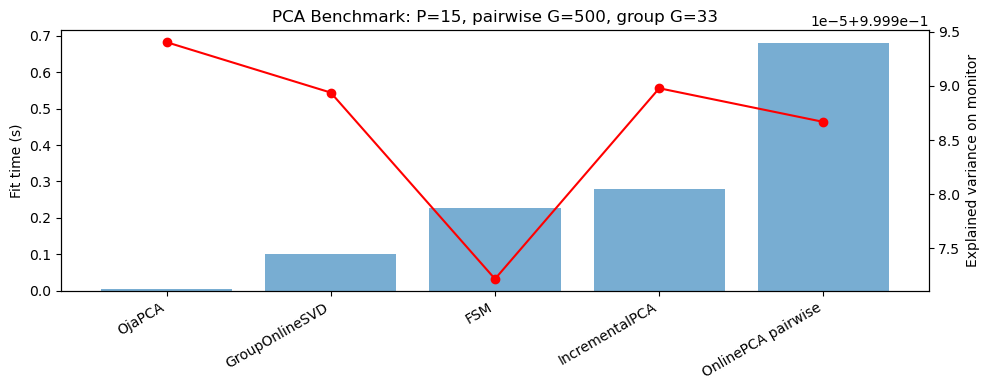

In [46]:
methods = [r["method"] for r in results]
times = [r["time"] for r in results]
evrs = [r["explained_variance"] for r in results]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(methods, times, alpha=0.6)
ax2.plot(methods, evrs, "o-", color="red")

ax1.set_ylabel("Fit time (s)")
ax2.set_ylabel("Explained variance on monitor")
ax1.set_xticklabels(methods, rotation=30, ha="right")

plt.title(f"PCA Benchmark: P={P}, pairwise G={G}, group G={GROUP_G}")
plt.tight_layout()
plt.show()

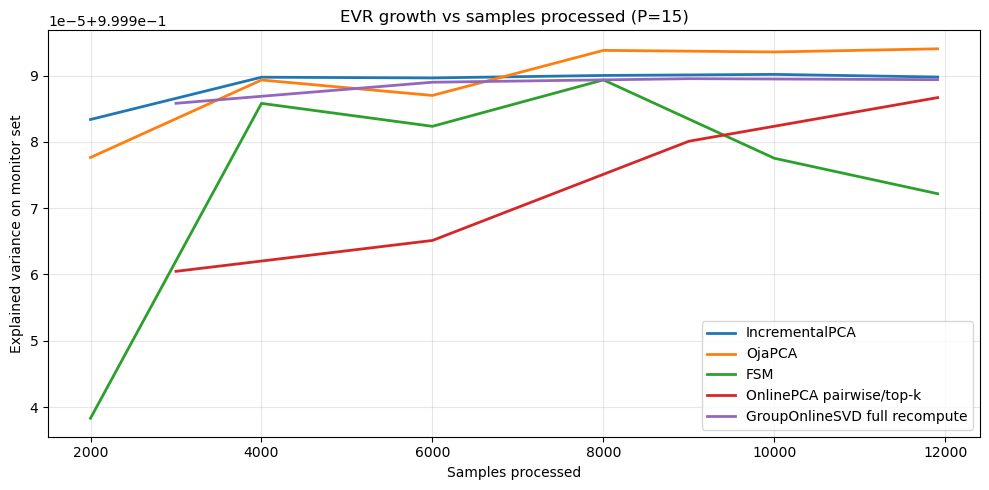

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(ipca_samples, ipca_tr, lw=2, label="IncrementalPCA")
plt.plot(oja_samples, oja_tr, lw=2, label="OjaPCA")
plt.plot(fsm_samples, fsm_tr, lw=2, label="FSM")
plt.plot(online_samples, online_tr, lw=2, label="OnlinePCA pairwise/top-k")
plt.plot(group_samples, group_tr, lw=2, label="GroupOnlineSVD full recompute")

plt.xlabel("Samples processed")
plt.ylabel("Explained variance on monitor set")
plt.title(f"EVR growth vs samples processed (P={P})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

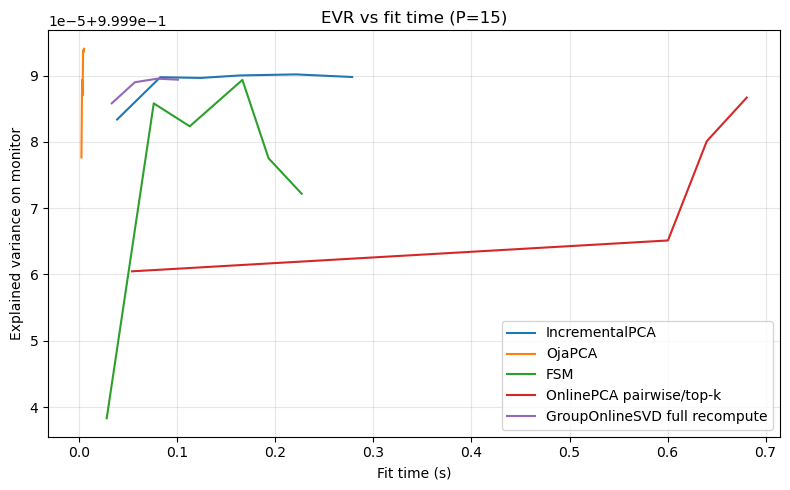

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(ipca_time_axis, ipca_tr, label="IncrementalPCA")
plt.plot(oja_time_axis, oja_tr, label="OjaPCA")
plt.plot(fsm_time_axis, fsm_tr, label="FSM")
plt.plot(online_time_axis, online_tr, label="OnlinePCA pairwise/top-k")
plt.plot(group_time_axis, group_tr, label="GroupOnlineSVD full recompute")

plt.xlabel("Fit time (s)")
plt.ylabel("Explained variance on monitor")
plt.title(f"EVR vs fit time (P={P})")
# plt.xlim(0, 10)
# plt.ylim(0.3, 0.85)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()